# 01 - The forward operator A: a gallery

Lecture section: 2 (the physics)  |  Spine term this tutorial changes: **D** (the operator A and the data $y$)

$$\hat{x} = \arg\min_x\ \underbrace{D(Ax, y)}_{\text{data fidelity}} + \underbrace{R(x)}_{\text{prior}}$$

Before we reconstruct anything, we meet the *forward* direction: an object $x$
goes **into** an instrument $A$ and comes **out** as measurements $y = A x + n$.
Different machines (CT, MRI, a camera lens, a sensor with dead pixels) are wildly
different physics, yet in `deepinv` they all wear the **same coat**: every one is
a `physics` object exposing `.A` (forward), `.A_adjoint` (transpose) and
`.A_dagger` (pseudo-inverse). That shared interface *is* the **D** in the spine.

A word on `.A_dagger`: in general there is no closed-form inverse, so by default
`deepinv` computes it with a **quick, simple iterative solver** (a few
conjugate-gradient steps on the least-squares problem $\min_x \|Ax - y\|^2$) to
*approximately* undo $A$. Some modalities override this with a fast classical
formula (filtered back-projection for CT, zero-filling for MRI). Either way it is
a cheap first estimate, **not** yet a real reconstruction -- that is the job of
the prior $R$.

This notebook is a gallery: one row per modality, `x | y | quick inverse`.

In [1]:
import tutorial_common as tc
import deepinv as dinv
import torch
import torch.nn.functional as F

tc.set_seed()

deepinv 0.4.1 | torch 2.9.1 | device cpu


## CT (computed tomography)

**X-ray tomography.** We send rays through the object at many angles; each
measurement is a line integral. Stacking them gives the **sinogram** $y = A x$,
with axes **[detector cell, angle]**: one column per projection angle. The quick
inverse `phys.fbp(y)` is the *filtered back-projection* -- a fast, classical
estimate.

**First, a case where it works.** With **many angles** (here 180) and **no
noise**, $A$ is well-conditioned and FBP recovers the object almost perfectly.
This is the easy regime.

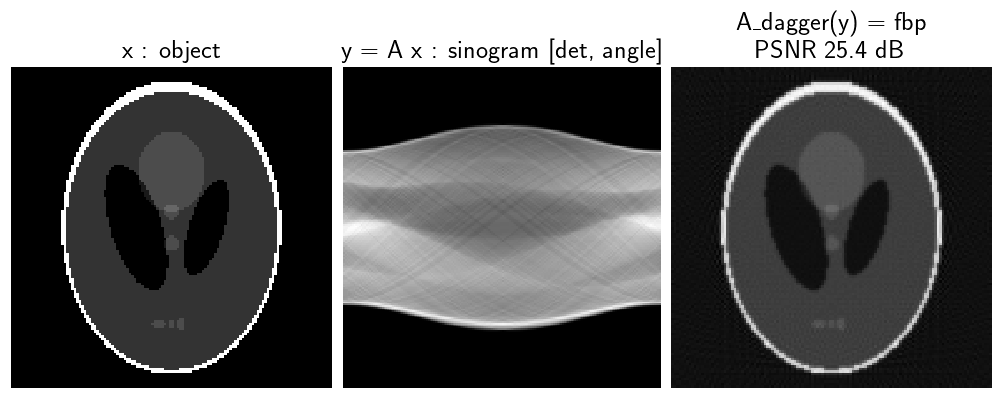

In [2]:
x_ct = tc.load_object(128)                        # (1,1,128,128) phantom in [0,1]
phys_ok = tc.ct_physics(angles=180, sigma=0.0)    # many angles, no noise -> well-posed
y_ok = phys_ok.A(x_ct)                            # clean sinogram A x
x_fbp_ok = phys_ok.fbp(y_ok)                      # fast filtered back-projection

tc.show_images(
    [x_ct, y_ok, x_fbp_ok],
    titles=["x : object",
            "y = A x : sinogram [det, angle]",
            tc.title_psnr("A_dagger(y) = fbp", x_fbp_ok, x_ct)],
    figsize=(9, 4),
)

**Now a case where it fails.** Drop to **few angles** (here 20) and add a little
measurement noise, and the *same* FBP becomes streaky and noisy: $A$ no longer
sees enough of the object, and inverting it amplifies the noise. This
**sparse-view, noisy CT** is exactly the **recurring problem** for tutorials 2-5
(fixed there at 40 angles, notebook 2 at 20) -- the physics $A$ stays fixed and
only the prior $R$ changes to close this gap.

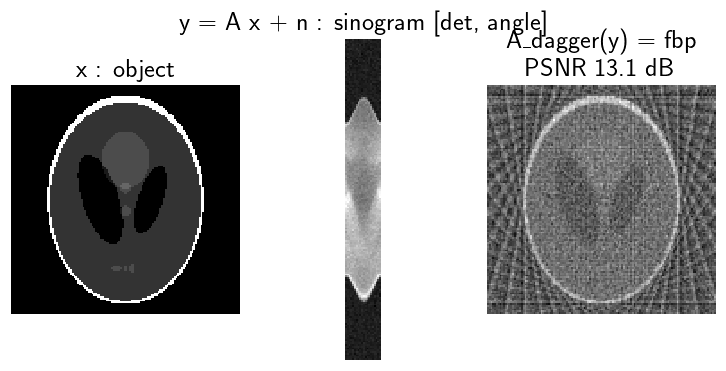

In [3]:
phys_ct = tc.ct_physics(angles=20, sigma=0.02)   # few angles + noise -> ill-posed
y_ct = phys_ct(x_ct)                             # phys(x) = A x + n  (noisy sinogram)
x_fbp = phys_ct.fbp(y_ct)                        # same FBP, now streaky and noisy

tc.show_images(
    [x_ct, y_ct, x_fbp],
    titles=["x : object",
            "y = A x + n : sinogram [det, angle]",
            tc.title_psnr("A_dagger(y) = fbp", x_fbp, x_ct)],
    figsize=(9, 4),
)

## MRI (k-space sampling)

An MRI scanner measures the **Fourier transform** of the object, then subsamples
it to go faster: $A$ = "Fourier transform, then keep only the masked frequencies"
(here `acceleration=4`, so we keep ~1/4 of k-space). Because the FFT is complex,
the input is a **2-channel real** tensor (real, imaginary).

The quick inverse is the **zero-filled** reconstruction `A_adjoint(y)`. The
adjoint does two simple things: first it puts the measured frequencies back where
they belong and **fills the un-measured (masked) locations with zeros**, giving a
full but incomplete k-space; then it applies the **inverse Fourier transform** to
return to image space. The missing frequencies show up as the aliasing artifacts
that a prior must later clean up.

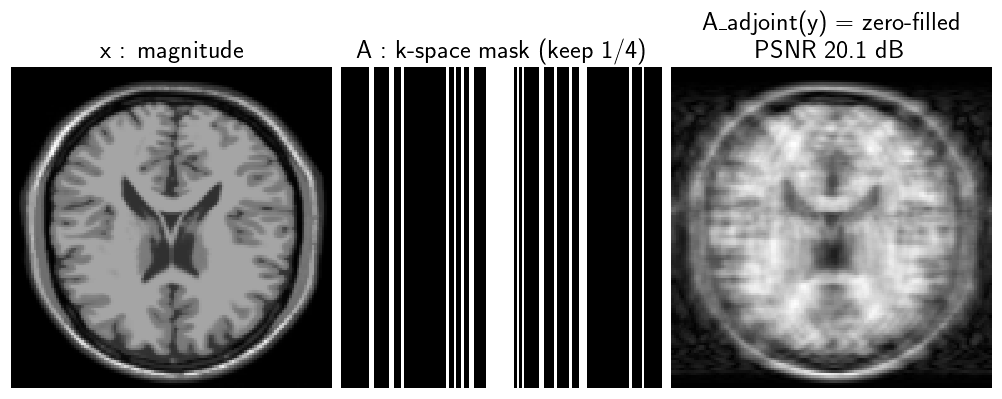

In [4]:
# Modality-appropriate image: a brain slice (recipe 1).
vol = dinv.utils.load_example("brainweb_t1_ICBM_1mm_subject_0.npy", device=tc.DEVICE)
sl = vol[vol.shape[0] // 2].unsqueeze(0).unsqueeze(0)            # mid-slice (1,1,217,181)
x_brain = F.interpolate(sl / sl.max(), size=(128, 128), mode="bilinear",
                        align_corners=False)                    # (1,1,128,128) in [0,1]

x_mri = torch.cat([x_brain, torch.zeros_like(x_brain)], dim=1)  # 2-ch real input (1,2,H,W)
mask = dinv.physics.generator.GaussianMaskGenerator(
    img_size=(128, 128), acceleration=4, device=tc.DEVICE).step()["mask"]
phys_mri = dinv.physics.MRI(mask=mask, img_size=(128, 128), device=tc.DEVICE)

y_mri = phys_mri.A(x_mri)                                       # masked k-space (1,2,H,W)
x_zf = phys_mri.A_adjoint(y_mri)                                # zero-filled (1,2,H,W)
mag_zf = torch.sqrt(x_zf[:, 0:1] ** 2 + x_zf[:, 1:2] ** 2)     # magnitude to display

tc.show_images(
    [x_brain, mask, mag_zf],
    titles=["x : magnitude",
            "A : k-space mask (keep 1/4)",
            tc.title_psnr("A_adjoint(y) = zero-filled", mag_zf, x_brain)],
    figsize=(9, 4),
)

## Blur (a camera lens / deconvolution)

A simple optical system convolves the scene with a blur **kernel**. We use
`BlurFFT` (circular convolution via the FFT), which keeps the image size fixed.
The quick inverse `A_dagger(y)` is the pseudo-inverse deblur, which divides the
measurement by the blur's frequency response.

**Where it works:** with **no noise**, that division undoes the blur cleanly and
`A_dagger(y)` recovers a sharp image.

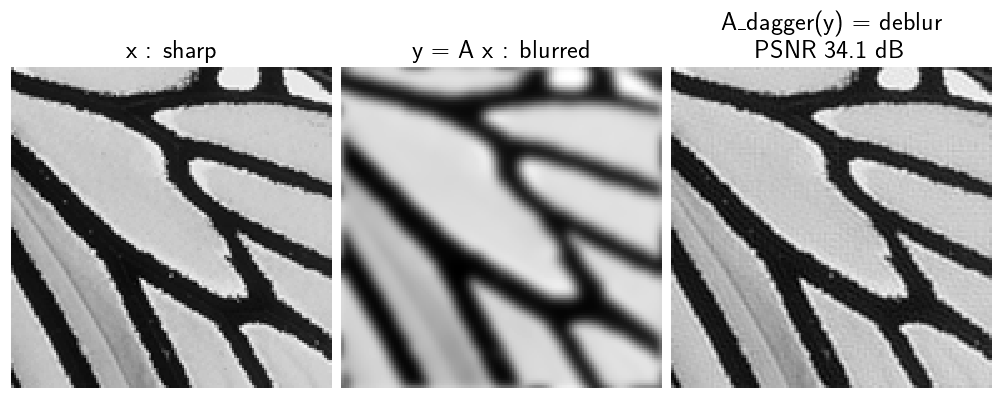

In [5]:
x_bf = dinv.utils.load_example("butterfly.png", img_size=(128, 128),
                               grayscale=True, device=tc.DEVICE)
kernel = dinv.physics.functional.gaussian_blur(sigma=(2, 2))  # (1,1,15,15) Gaussian PSF
phys_blur = dinv.physics.BlurFFT(img_size=(1, 128, 128), filter=kernel, device=tc.DEVICE)

y_blur = phys_blur.A(x_bf)                                     # blurred measurement
x_deblur = phys_blur.A_dagger(y_blur)                          # pseudo-inverse deblur

tc.show_images(
    [x_bf, y_blur, x_deblur],
    titles=["x : sharp",
            "y = A x : blurred",
            tc.title_psnr("A_dagger(y) = deblur", x_deblur, x_bf)],
    figsize=(9, 4),
)

**Where it fails:** add even a **little measurement noise** ($\sigma = 0.02$) and
the same pseudo-inverse deblur is *treacherous*. Dividing by the blur's tiny
high-frequency response amplifies that noise enormously, so `A_dagger(y)` explodes
into noise -- the range blows well past $[0,1]$. This noise amplification is
exactly what the next notebook dissects, and why we need a prior.

A_dagger(y) range [-1609.5, 1429.9]  <- far outside [0,1]


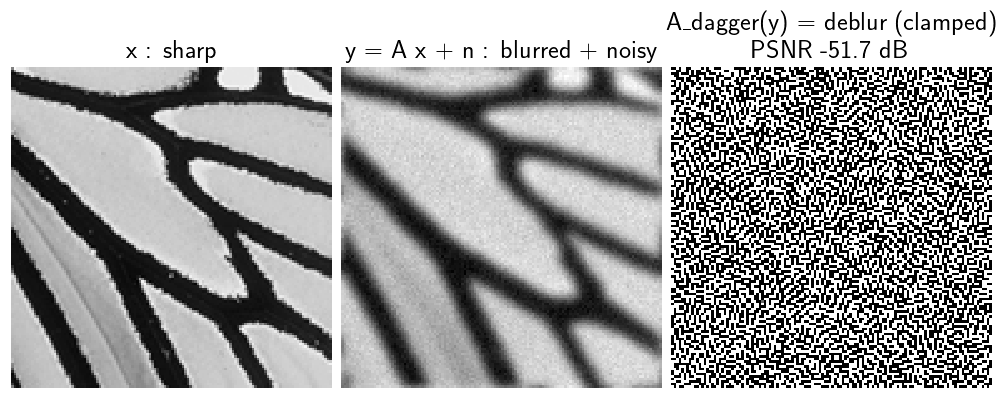

In [6]:
phys_blur_noisy = dinv.physics.BlurFFT(
    img_size=(1, 128, 128), filter=kernel, device=tc.DEVICE,
    noise_model=dinv.physics.GaussianNoise(sigma=0.02))       # noise inside the physics

y_blur_n = phys_blur_noisy(x_bf)                              # blurred + noisy measurement
x_deblur_n = phys_blur_noisy.A_dagger(y_blur_n)              # same deblur, now explodes
print(f"A_dagger(y) range [{x_deblur_n.min():.1f}, {x_deblur_n.max():.1f}]  <- far outside [0,1]")

tc.show_images(
    [x_bf, y_blur_n, x_deblur_n.clamp(0, 1)],
    titles=["x : sharp",
            "y = A x + n : blurred + noisy",
            tc.title_psnr("A_dagger(y) = deblur (clamped)", x_deblur_n, x_bf)],
    figsize=(9, 4),
)

## Inpainting (missing pixels)

A sensor with dead pixels, or deliberate subsampling: $A$ simply **keeps a random
50% of pixels** and discards the rest (a diagonal 0/1 mask). The measurement $y$
is the object with half its pixels blacked out. There is no clever closed-form
inverse for the missing pixels -- the masked $y$ *is* the naive "reconstruction",
and a prior is what fills the holes later.

Unlike CT/MRI/blur, inpainting is not really a physical instrument: it is more of
a **machine-learning** setting, where the "prior" that fills the holes is
typically **learned from data** rather than hand-crafted.

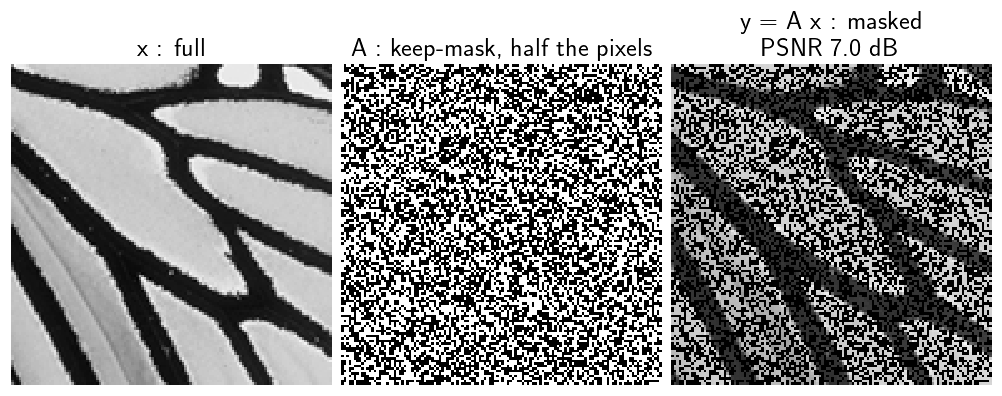

In [7]:
phys_inp = dinv.physics.Inpainting(img_size=(1, 128, 128), mask=0.5, device=tc.DEVICE)
y_inp = phys_inp.A(x_bf)                                       # 50% of pixels zeroed

tc.show_images(
    [x_bf, phys_inp.mask, y_inp],
    titles=["x : full",
            "A : keep-mask, half the pixels",
            tc.title_psnr("y = A x : masked", y_inp, x_bf)],
    figsize=(9, 4),
)

## One interface, even for nonlinear physics

Not every operator is a matrix. **Phase retrieval** measures only intensities,
$y = |Bx|^2$, throwing away the phase -- a *nonlinear* forward map on a *complex*
input (`dinv.physics.RandomPhaseRetrieval(m=..., img_size=...)`). We skip its
figure here, but the point stands: it *still* exposes the same `.A` / `.A_adjoint`
interface as everything above.

The crucial habits, true for **every** modality in the gallery:

- `phys.A(x)`  -- the clean forward operator $A x$ (deterministic);
- `phys.A_adjoint(y)` -- the transpose $A^\top y$ (the cheap "back-projection");
- `phys.A_dagger(y)`  -- the pseudo-inverse (best linear undo, no prior);
- **noise is applied by `phys(x)`, not by `phys.A(x)`** -- the measurement is
  $y = A x + n$, and that physics-plus-noise pair is precisely the data term
  $D(Ax, y)$ in the spine.

## Takeaway

Wildly different physics -- rays, Fourier samples, a lens, dead pixels -- all wear
**one operator interface** ($A$, $A^\top$, $A^\dagger$). Reconstruction is
recovering $x$ from $y$ given $A$, and that is the job of every notebook that
follows.